<a href="https://colab.research.google.com/github/D2718281828nis/class-lung_dynamics/blob/main/simple-lung-dymanics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

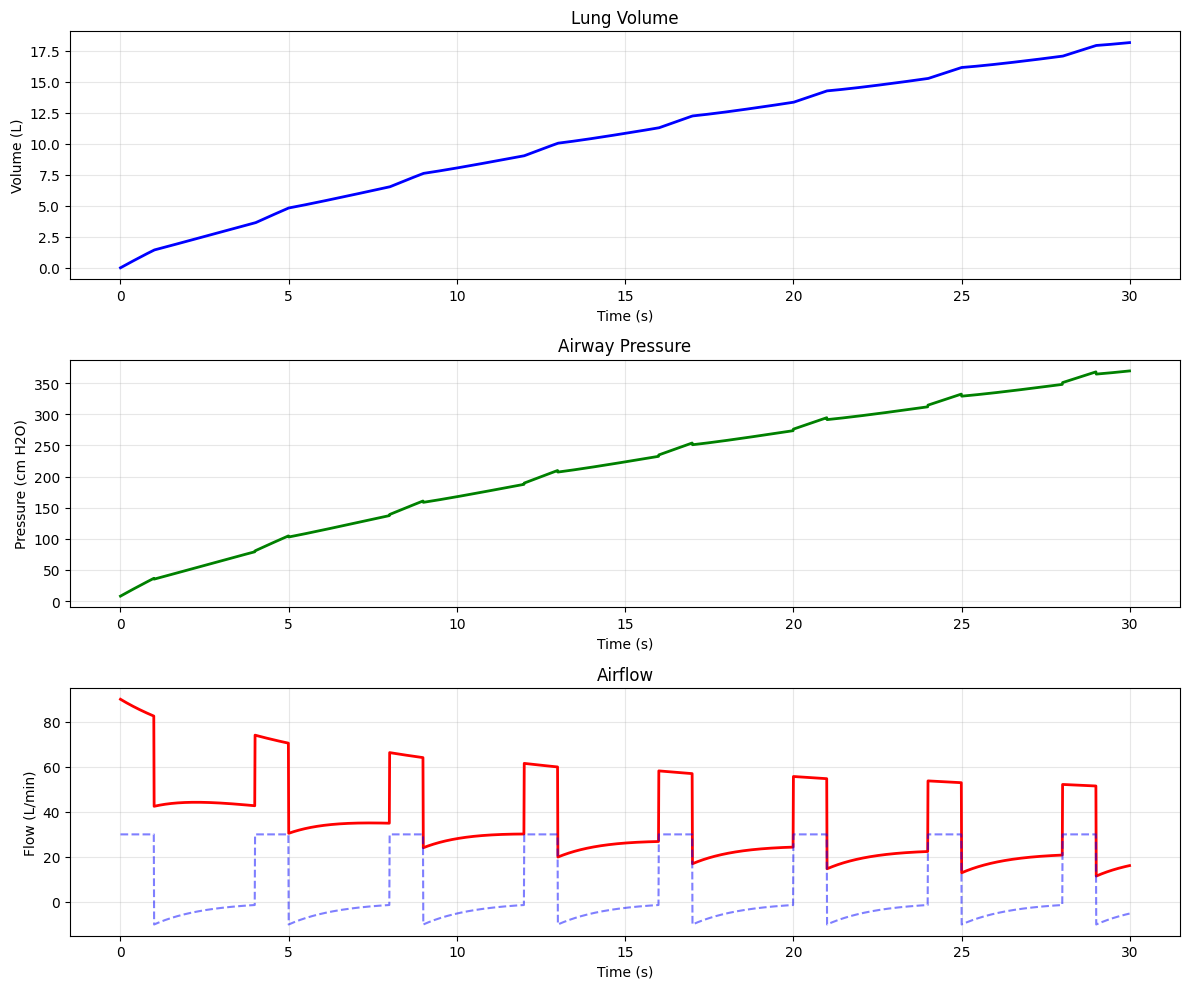

Max Volume: 18.158 L
Min Volume: 0.000 L
Tidal Volume: 18.158 L
Max Pressure: 369.7 cm H2O
Min Pressure: 8.0 cm H2O
Max Flow: 90.0 L/min
Min Flow: 11.5 L/min


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class VentilatorParameters:
    def __init__(self):
        self.compliance = 0.05
        self.resistance = 2.0
        self.tidal_volume = 0.5
        self.inspiratory_time = 1.0
        self.expiratory_time = 3.0
        self.breath_time = self.inspiratory_time + self.expiratory_time
        self.peep = 5.0
        self.muscle_pressure = 2.0

    def get_flow_profile(self, t):
        phase = t % self.breath_time
        if phase < self.inspiratory_time:
            flow = self.tidal_volume / self.inspiratory_time
        else:
            exp_elapsed = phase - self.inspiratory_time
            exp_ratio = exp_elapsed / self.expiratory_time
            flow = -self.tidal_volume / self.expiratory_time * np.exp(-exp_ratio * 2)
        return flow

class RespiratorySystem:
    def __init__(self, params):
        self.params = params

    def dynamics(self, state, t):
        V = state[0]
        Q_vent = self.params.get_flow_profile(t)
        R_eff = self.params.resistance * (1 + 0.1 * V / 1.0)
        P_lung = self.params.peep + V / self.params.compliance
        Q_total = Q_vent + self.params.muscle_pressure / R_eff
        dVdt = Q_total
        P_total = P_lung + R_eff * Q_total
        return [dVdt]

def simulate_ventilator(duration=30, dt=0.01):
    params = VentilatorParameters()
    system = RespiratorySystem(params)
    t = np.arange(0, duration, dt)
    n_steps = len(t)
    volume = np.zeros(n_steps)
    flow = np.zeros(n_steps)
    pressure = np.zeros(n_steps)
    ventilator_flow = np.zeros(n_steps)
    state = np.array([0.0])

    for i in range(n_steps):
        volume[i] = state[0]
        ventilator_flow[i] = params.get_flow_profile(t[i])
        V = state[0]
        R_eff = params.resistance * (1 + 0.1 * V / 1.0)
        Q_vent = ventilator_flow[i]
        P_lung = params.peep + V / params.compliance
        Q_total = Q_vent + params.muscle_pressure / R_eff
        flow[i] = Q_total
        pressure[i] = P_lung + R_eff * Q_total
        if i < n_steps - 1:
            dt_step = t[i+1] - t[i]
            state = state + np.array([Q_total]) * dt_step
            state[0] = max(state[0], 0.0)

    return t, volume, flow, pressure, ventilator_flow

t, volume, flow, pressure, v_flow = simulate_ventilator()

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(t, volume, 'b-', linewidth=2)
axes[0].set_ylabel('Volume (L)')
axes[0].set_xlabel('Time (s)')
axes[0].grid(True, alpha=0.3)
axes[0].set_title('Lung Volume')

axes[1].plot(t, pressure, 'g-', linewidth=2)
axes[1].set_ylabel('Pressure (cm H2O)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)
axes[1].set_title('Airway Pressure')

axes[2].plot(t, flow * 60, 'r-', linewidth=2)
axes[2].plot(t, v_flow * 60, 'b--', alpha=0.5)
axes[2].set_ylabel('Flow (L/min)')
axes[2].set_xlabel('Time (s)')
axes[2].grid(True, alpha=0.3)
axes[2].set_title('Airflow')

plt.tight_layout()
plt.show()

print(f"Max Volume: {np.max(volume):.3f} L")
print(f"Min Volume: {np.min(volume):.3f} L")
print(f"Tidal Volume: {np.max(volume) - np.min(volume):.3f} L")
print(f"Max Pressure: {np.max(pressure):.1f} cm H2O")
print(f"Min Pressure: {np.min(pressure):.1f} cm H2O")
print(f"Max Flow: {np.max(flow)*60:.1f} L/min")
print(f"Min Flow: {np.min(flow)*60:.1f} L/min")

# ODE model of lung

In [1]:
"""Reduced ODE model extracted from medical_ventilator_with_lung_model.engee.

The Engee lung subsystem contains a translational mechanical converter with
piston area A = 1 m^2, a spring (elastance) k = 980665 N/m, and a damper
(resistance) C = 196133 N/(m/s). Since V = A*x and Q = dV/dt = A*dx/dt,
its single-compartment respiratory equations are

    dV/dt = Q
    P_gauge = E * (V - V0) + R * Q - P_mus
    P_abs   = P_atm + P_gauge

where E = k/A^2 and R = C/A^2. In the file A=1, so E=k and R=C.
The supplied Muscle Pressure input is constant zero. Positive P_mus in this
class denotes inspiratory patient effort and therefore reduces required airway
pressure.

SI units are used internally:
    V: m^3, Q: m^3/s, P: Pa.
Convenience methods support L, L/s, L/min, and cmH2O.
"""

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Iterable, Literal, Optional, Union

import numpy as np

ArrayLike = Union[Iterable[float], np.ndarray]
Signal = Union[float, ArrayLike, Callable[[float], float]]

PA_PER_CMH2O = 98.0665
M3_PER_L = 1.0e-3


@dataclass(frozen=True)
class SimulationResult:
    """Time history returned by :meth:`VentilatorLungModel.simulate`."""

    time_s: np.ndarray
    flow_m3_s: np.ndarray
    volume_m3: np.ndarray
    pressure_gauge_pa: np.ndarray
    pressure_absolute_pa: np.ndarray

    @property
    def flow_l_s(self) -> np.ndarray:
        return self.flow_m3_s / M3_PER_L

    @property
    def flow_l_min(self) -> np.ndarray:
        return self.flow_l_s * 60.0

    @property
    def volume_l(self) -> np.ndarray:
        return self.volume_m3 / M3_PER_L

    @property
    def pressure_gauge_cmh2o(self) -> np.ndarray:
        return self.pressure_gauge_pa / PA_PER_CMH2O

    @property
    def pressure_absolute_cmh2o(self) -> np.ndarray:
        return self.pressure_absolute_pa / PA_PER_CMH2O


class VentilatorLungModel:
    """Single-compartment lung model with flow input and V/P outputs.

    Parameters are initialized from the uploaded Engee model.

    Parameters
    ----------
    elastance_pa_per_m3:
        Lung elastance E. Extracted value: 980665 Pa/m^3.
    resistance_pa_s_per_m3:
        Airway resistance R. Extracted value: 196133 Pa*s/m^3.
    reference_volume_m3:
        Volume at zero elastic recoil. The model uses a 2 mm piston offset with
        area 1 m^2, corresponding to 0.002 m^3 = 2 L.
    atmospheric_pressure_pa:
        Absolute ambient pressure used by the Engee sensors.
    initial_volume_m3:
        Initial state. Defaults to reference_volume_m3.
    """

    def __init__(
        self,
        elastance_pa_per_m3: float = 980_665.0,
        resistance_pa_s_per_m3: float = 196_133.0,
        reference_volume_m3: float = 2.0e-3,
        atmospheric_pressure_pa: float = 101_325.0,
        initial_volume_m3: Optional[float] = None,
    ) -> None:
        if elastance_pa_per_m3 <= 0.0:
            raise ValueError("elastance_pa_per_m3 must be positive")
        if resistance_pa_s_per_m3 < 0.0:
            raise ValueError("resistance_pa_s_per_m3 must be non-negative")
        if reference_volume_m3 < 0.0:
            raise ValueError("reference_volume_m3 must be non-negative")

        self.E = float(elastance_pa_per_m3)
        self.R = float(resistance_pa_s_per_m3)
        self.V0 = float(reference_volume_m3)
        self.P_atm = float(atmospheric_pressure_pa)
        self.V = float(self.V0 if initial_volume_m3 is None else initial_volume_m3)

    @property
    def elastance_cmh2o_per_l(self) -> float:
        return self.E * M3_PER_L / PA_PER_CMH2O

    @property
    def resistance_cmh2o_per_l_s(self) -> float:
        return self.R * M3_PER_L / PA_PER_CMH2O

    def reset(self, volume_m3: Optional[float] = None) -> None:
        """Reset the state to the reference volume or a specified volume."""
        self.V = float(self.V0 if volume_m3 is None else volume_m3)

    def derivative(self, t_s: float, volume_m3: float, flow_m3_s: float) -> float:
        """ODE right-hand side dV/dt = Q."""
        del t_s, volume_m3
        return float(flow_m3_s)

    def pressure_gauge_pa(
        self,
        flow_m3_s: float,
        volume_m3: Optional[float] = None,
        muscle_pressure_pa: float = 0.0,
    ) -> float:
        """Return airway pressure relative to atmosphere."""
        v = self.V if volume_m3 is None else float(volume_m3)
        return self.E * (v - self.V0) + self.R * float(flow_m3_s) - float(muscle_pressure_pa)

    def output(
        self,
        flow_m3_s: float,
        muscle_pressure_pa: float = 0.0,
    ) -> tuple[float, float]:
        """Return current ``(V_m3, P_gauge_Pa)`` for input flow Q."""
        return self.V, self.pressure_gauge_pa(flow_m3_s, muscle_pressure_pa=muscle_pressure_pa)

    def step(
        self,
        flow_m3_s: float,
        dt_s: float,
        muscle_pressure_pa: float = 0.0,
        method: Literal["euler"] = "euler",
    ) -> tuple[float, float]:
        """Advance one sample and return ``(V_m3, P_gauge_Pa)``.

        Pressure is evaluated at the updated volume and current flow.
        """
        if dt_s <= 0.0:
            raise ValueError("dt_s must be positive")
        if method != "euler":
            raise ValueError("Only 'euler' is needed because dV/dt is the prescribed input Q")

        self.V += float(dt_s) * float(flow_m3_s)
        p = self.pressure_gauge_pa(flow_m3_s, muscle_pressure_pa=muscle_pressure_pa)
        return self.V, p

    @staticmethod
    def _sample_signal(signal: Signal, t: np.ndarray, name: str) -> np.ndarray:
        if callable(signal):
            values = np.asarray([signal(float(ti)) for ti in t], dtype=float)
        elif np.isscalar(signal):
            values = np.full(t.shape, float(signal), dtype=float)
        else:
            values = np.asarray(signal, dtype=float)
            if values.shape != t.shape:
                raise ValueError(f"{name} must have the same shape as time_s")
        if not np.all(np.isfinite(values)):
            raise ValueError(f"{name} contains NaN or infinite values")
        return values

    def simulate(
        self,
        time_s: ArrayLike,
        flow: Signal,
        *,
        flow_unit: Literal["m3/s", "L/s", "L/min"] = "m3/s",
        muscle_pressure: Signal = 0.0,
        muscle_pressure_unit: Literal["Pa", "cmH2O"] = "Pa",
        reset: bool = True,
        integration: Literal["trapezoid", "euler"] = "trapezoid",
    ) -> SimulationResult:
        """Simulate prescribed flow Q(t).

        ``time_s`` must be strictly increasing. Array signals are sampled at the
        same times; callables receive time in seconds. Trapezoidal integration is
        the default and exactly integrates piecewise-linear input flow.
        """
        t = np.asarray(time_s, dtype=float)
        if t.ndim != 1 or t.size < 2:
            raise ValueError("time_s must be a one-dimensional array with at least two points")
        dt = np.diff(t)
        if not np.all(np.isfinite(t)) or np.any(dt <= 0.0):
            raise ValueError("time_s must be finite and strictly increasing")

        q = self._sample_signal(flow, t, "flow")
        if flow_unit == "L/s":
            q *= M3_PER_L
        elif flow_unit == "L/min":
            q *= M3_PER_L / 60.0
        elif flow_unit != "m3/s":
            raise ValueError("flow_unit must be 'm3/s', 'L/s', or 'L/min'")

        p_mus = self._sample_signal(muscle_pressure, t, "muscle_pressure")
        if muscle_pressure_unit == "cmH2O":
            p_mus *= PA_PER_CMH2O
        elif muscle_pressure_unit != "Pa":
            raise ValueError("muscle_pressure_unit must be 'Pa' or 'cmH2O'")

        if reset:
            self.reset()

        v = np.empty_like(t)
        v[0] = self.V
        if integration == "trapezoid":
            increments = 0.5 * (q[:-1] + q[1:]) * dt
        elif integration == "euler":
            increments = q[:-1] * dt
        else:
            raise ValueError("integration must be 'trapezoid' or 'euler'")
        v[1:] = v[0] + np.cumsum(increments)

        p_gauge = self.E * (v - self.V0) + self.R * q - p_mus
        p_abs = self.P_atm + p_gauge
        self.V = float(v[-1])

        return SimulationResult(
            time_s=t,
            flow_m3_s=q,
            volume_m3=v,
            pressure_gauge_pa=p_gauge,
            pressure_absolute_pa=p_abs,
        )


if __name__ == "__main__":
    # Example: 0.5 L/s inspiration for 1 s, then zero flow for 1 s.
    model = VentilatorLungModel()
    time = np.linspace(0.0, 2.0, 2001)
    flow_l_s = np.where(time < 1.0, 0.5, 0.0)
    result = model.simulate(time, flow_l_s, flow_unit="L/s")

    print(f"E = {model.elastance_cmh2o_per_l:.3f} cmH2O/L")
    print(f"R = {model.resistance_cmh2o_per_l_s:.3f} cmH2O/(L/s)")
    print(f"Final V = {result.volume_l[-1]:.3f} L")
    print(f"Final P = {result.pressure_gauge_cmh2o[-1]:.3f} cmH2O")

E = 10.000 cmH2O/L
R = 2.000 cmH2O/(L/s)
Final V = 2.500 L
Final P = 4.998 cmH2O


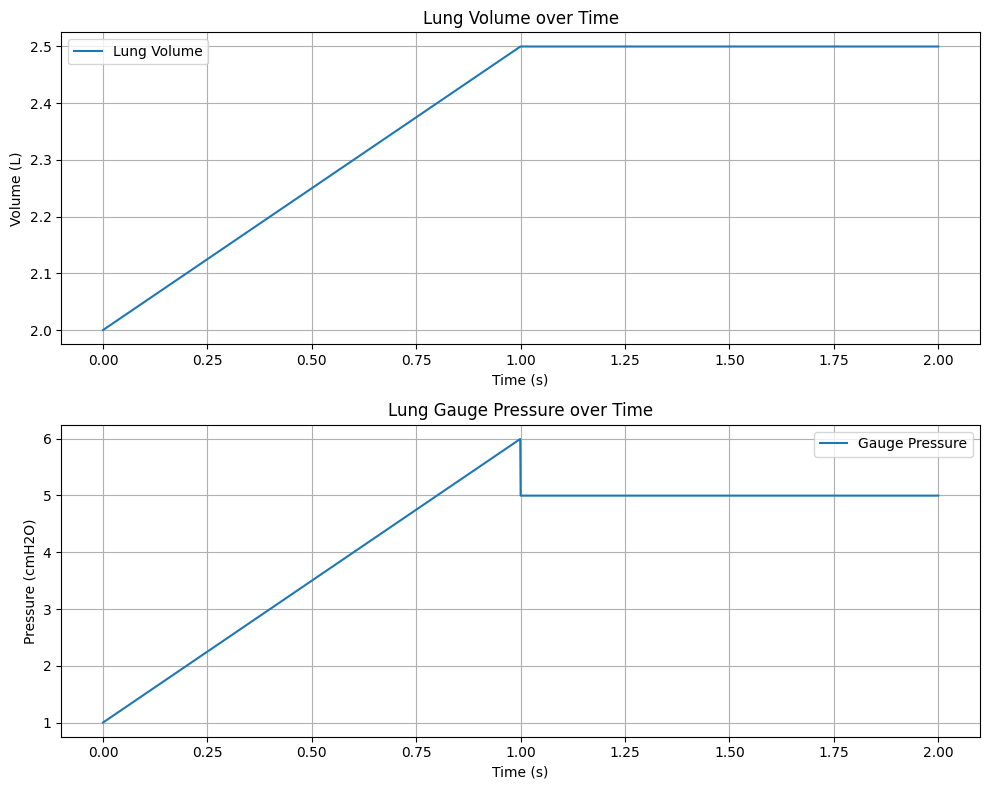


--- System Stage Analysis ---

Stage 1: Inspiration (0s to 1.0s)
During inspiration, flow is constant at 0.5 L/s.
  - Volume increases steadily, reaching approximately 2.50 L.
  - Pressure increases due to both elastic recoil and resistive forces, peaking around 6.00 cmH2O at the end of inspiration.

Stage 2: Zero Flow (1.0s to 2s)
After inspiration, flow drops to zero.
  - The model holds the inspired volume, thus volume remains constant around 2.50 L.
  - With zero flow, the resistive pressure component becomes zero. The pressure reflects only the elastic recoil of the lung, which remains constant with the held volume, approximately 5.00 cmH2O.


In [2]:
import matplotlib.pyplot as plt

# Assuming 'result' object from the previous cell is available in the kernel
# result = model.simulate(time, flow_l_s, flow_unit="L/s")

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Plot Volume
axes[0].plot(result.time_s, result.volume_l, label='Lung Volume')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Volume (L)')
axes[0].set_title('Lung Volume over Time')
axes[0].grid(True)
axes[0].legend()

# Plot Pressure
axes[1].plot(result.time_s, result.pressure_gauge_cmh2o, label='Gauge Pressure')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Pressure (cmH2O)')
axes[1].set_title('Lung Gauge Pressure over Time')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n--- System Stage Analysis ---")

inspiration_end_time = 1.0 # From the example in the previous cell

# Stage 1: Inspiration (0s to 1s)
print(f"\nStage 1: Inspiration (0s to {inspiration_end_time}s)")
# Find the index corresponding to the end of inspiration
idx_inspiration_end = np.where(result.time_s <= inspiration_end_time)[0][-1]

max_volume_inspiration = np.max(result.volume_l[:idx_inspiration_end + 1])
max_pressure_inspiration = np.max(result.pressure_gauge_cmh2o[:idx_inspiration_end + 1])

print(f"During inspiration, flow is constant at 0.5 L/s.")
print(f"  - Volume increases steadily, reaching approximately {max_volume_inspiration:.2f} L.")
print(f"  - Pressure increases due to both elastic recoil and resistive forces, peaking around {max_pressure_inspiration:.2f} cmH2O at the end of inspiration.")

# Stage 2: Zero Flow (1s to 2s)
print(f"\nStage 2: Zero Flow ({inspiration_end_time}s to {result.time_s[-1]:.0f}s)")
min_volume_expiration = np.min(result.volume_l[idx_inspiration_end + 1:])
min_pressure_expiration = np.min(result.pressure_gauge_cmh2o[idx_inspiration_end + 1:])

print(f"After inspiration, flow drops to zero.")
print(f"  - The model holds the inspired volume, thus volume remains constant around {result.volume_l[-1]:.2f} L.")
print(f"  - With zero flow, the resistive pressure component becomes zero. The pressure reflects only the elastic recoil of the lung, which remains constant with the held volume, approximately {result.pressure_gauge_cmh2o[-1]:.2f} cmH2O.")
